# House Price Prediction Project

This notebook builds an end-to-end house price prediction workflow using the Kaggle house price dataset. It covers loading, inspection, cleaning, feature engineering, exploratory analysis, model training, evaluation, and export.

## 1. Project Introduction

The goal of this project is to predict house prices from structured real estate listing data. We clean messy price and area fields, reduce high-cardinality categories, remove outliers, train multiple regression models, and export the best model for reuse.

## 2. Import Libraries

In [37]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import inspect
import numpy as np
import pandas as pd
import seaborn as sns
from joblib import dump, load
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

PROJECT_DIR = Path.cwd().resolve()
if (PROJECT_DIR / 'house_prices.csv').exists():
    DATA_PATH = PROJECT_DIR / 'house_prices.csv'
else:
    DATA_PATH = PROJECT_DIR.parent / 'house_prices.csv'

OUTPUT_DIR = PROJECT_DIR
RANDOM_STATE = 42

## 3. Load Dataset

The dataset is loaded from `house_prices.csv` using pandas. We inspect the shape, column names, summary statistics, and missing values before any cleaning.

In [38]:
assert DATA_PATH.exists(), f'Dataset not found at {DATA_PATH}'

df = pd.read_csv(DATA_PATH, engine='python', on_bad_lines='skip')
print('Loaded dataset from:', DATA_PATH)
print('Shape:', df.shape)
df.head()

Loaded dataset from: G:\ML-house-price\house_prices.csv
Shape: (187531, 21)


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [39]:
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])
print('\nColumns list:')
print(df.columns.tolist())
print('\nInfo:')
print(df.info())
print('\nDescribe:')
print(df.describe(include='all').T)
print('\nMissing values:')
print(df.isna().sum().sort_values(ascending=False))

numeric_columns = df.select_dtypes(include=['number']).columns.tolist()
categorical_columns = df.select_dtypes(exclude=['number']).columns.tolist()

print('\nNumeric columns:')
print(numeric_columns)
print('\nCategorical columns:')
print(categorical_columns)

Rows: 187531
Columns: 21

Columns list:
['Index', 'Title', 'Description', 'Amount(in rupees)', 'Price (in rupees)', 'location', 'Carpet Area', 'Status', 'Floor', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society', 'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area', 'Dimensions', 'Plot Area']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        

### Dataset Summary

- Number of rows: printed in the inspection cell above.
- Number of columns: printed in the inspection cell above.
- Numeric columns: identified by pandas numeric dtypes.
- Categorical columns: the remaining object-style columns.
- Missing values: several fields such as `Super Area`, `Car Parking`, `Balcony`, `Society`, and `Dimensions` contain substantial missingness and need careful handling.

## 4. Exploratory Data Analysis

We visualize the target and a few important feature relationships before cleaning.

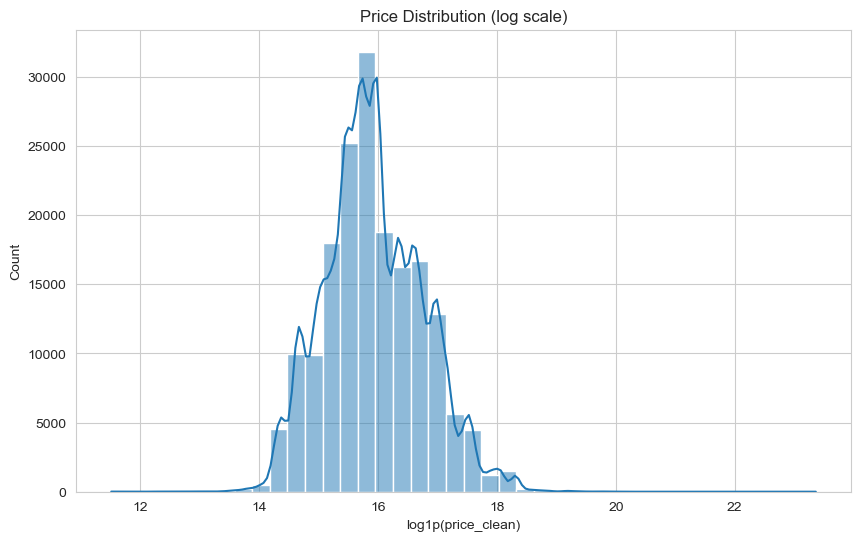

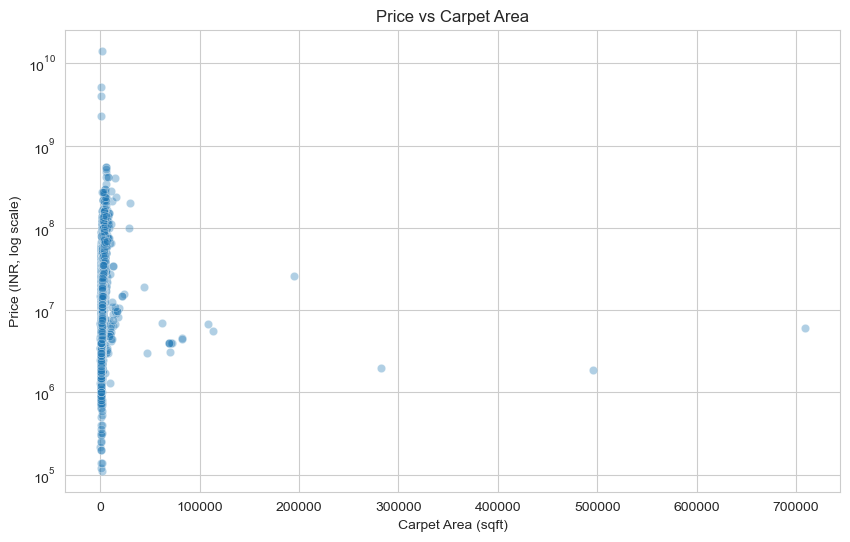

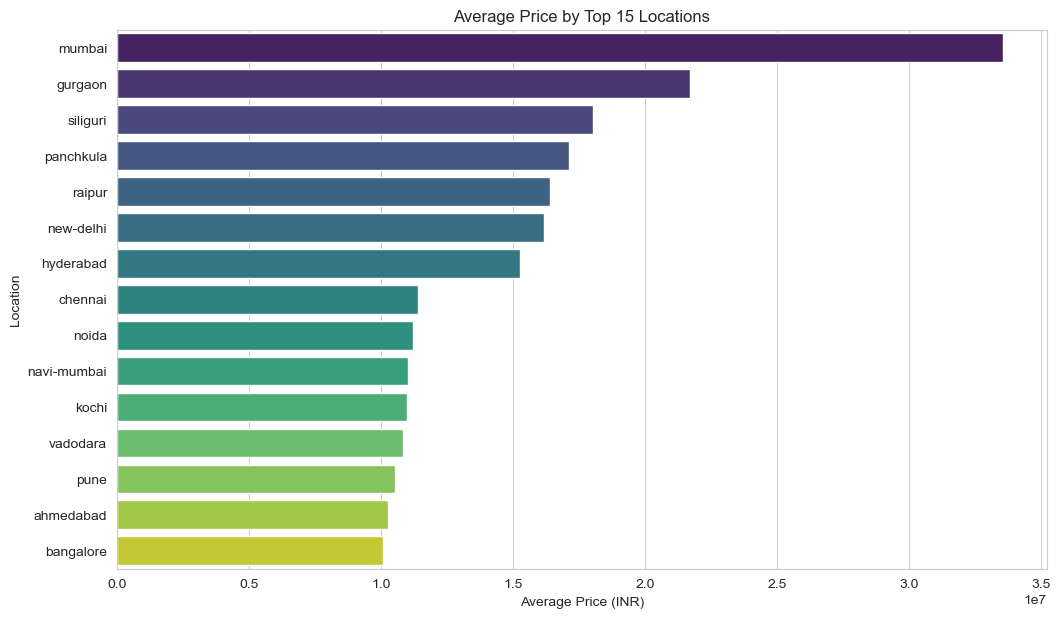

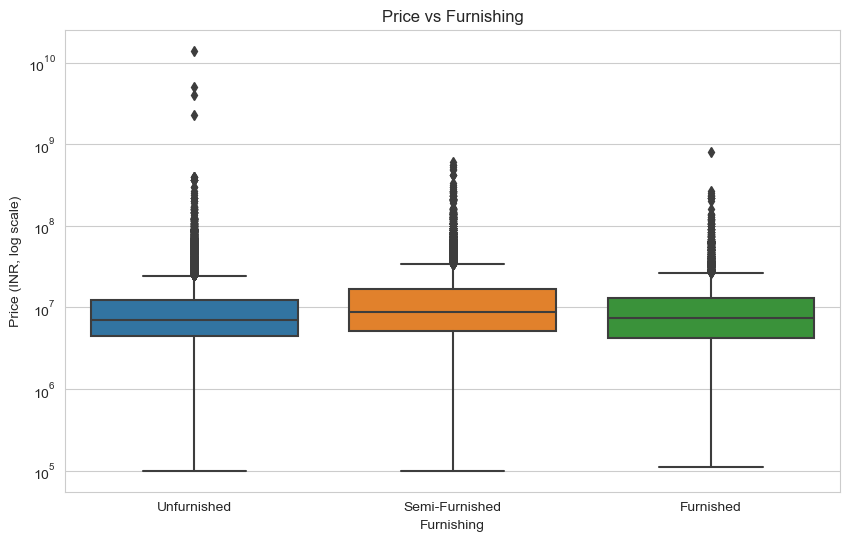

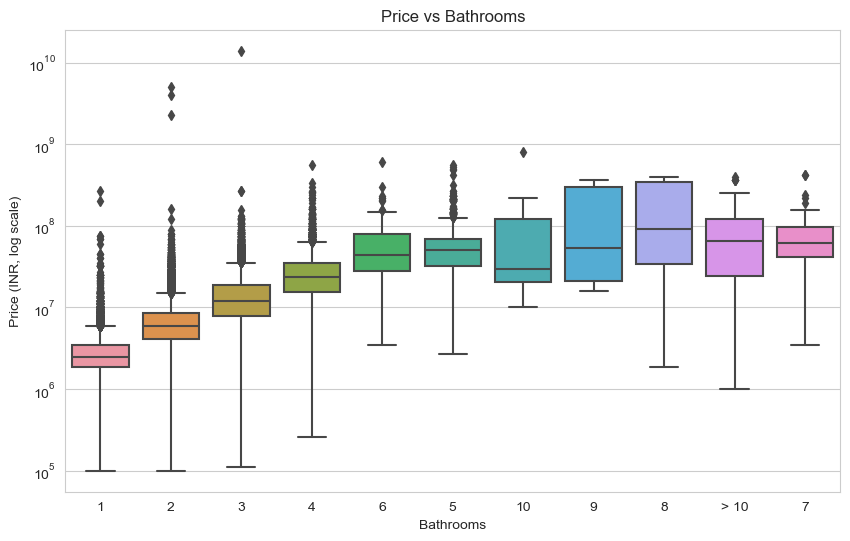

In [40]:
def parse_price(value: object) -> float:
    if pd.isna(value):
        return np.nan
    text = str(value).strip().lower().replace(',', '')
    if text in {'', 'na', 'n/a', 'none', 'call for price'}:
        return np.nan
    if text.endswith('lac'):
        return float(text[:-3].strip()) * 100000
    if text.endswith('cr'):
        return float(text[:-2].strip()) * 10000000
    return float(text)


def parse_area_to_sqft(value: object) -> float:
    if pd.isna(value):
        return np.nan
    text = str(value).strip().lower().replace(',', '')
    if text in {'', 'na', 'n/a', 'none'}:
        return np.nan
    is_sqm = 'sqm' in text or 'sq m' in text
    text = text.replace('sqft', '').replace('sq ft', '').replace('sqm', '').replace('sq m', '').strip()
    try:
        numeric_value = float(text)
    except ValueError:
        return np.nan
    return numeric_value * 10.764 if is_sqm else numeric_value


def parse_floor(value: object) -> float:
    if pd.isna(value):
        return np.nan
    text = str(value).strip().lower()
    if text.startswith('ground'):
        return 0.0
    if text.startswith('basement'):
        return -1.0
    if 'out of' in text:
        text = text.split('out of', 1)[0].strip()
    digits = ''.join(character for character in text if character.isdigit() or character == '.')
    return float(digits) if digits else np.nan


def parse_numeric(value: object) -> float:
    if pd.isna(value):
        return np.nan
    digits = ''.join(character for character in str(value) if character.isdigit() or character == '.')
    return float(digits) if digits else np.nan


eda_df = df.copy()
eda_df['price_clean'] = eda_df['Amount(in rupees)'].apply(parse_price)
eda_df['carpet_area_sqft'] = eda_df['Carpet Area'].apply(parse_area_to_sqft)
eda_df['bathroom_num'] = pd.to_numeric(eda_df['Bathroom'], errors='coerce')

plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(eda_df['price_clean'].dropna()), bins=40, kde=True)
plt.title('Price Distribution (log scale)')
plt.xlabel('log1p(price_clean)')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=eda_df, x='carpet_area_sqft', y='price_clean', alpha=0.35)
plt.yscale('log')
plt.title('Price vs Carpet Area')
plt.xlabel('Carpet Area (sqft)')
plt.ylabel('Price (INR, log scale)')
plt.show()

top_locations = eda_df.groupby('location')['price_clean'].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(12, 7))
sns.barplot(x=top_locations.values, y=top_locations.index, palette='viridis')
plt.title('Average Price by Top 15 Locations')
plt.xlabel('Average Price (INR)')
plt.ylabel('Location')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=eda_df, x='Furnishing', y='price_clean')
plt.yscale('log')
plt.title('Price vs Furnishing')
plt.xlabel('Furnishing')
plt.ylabel('Price (INR, log scale)')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=eda_df, x='Bathroom', y='price_clean')
plt.yscale('log')
plt.title('Price vs Bathrooms')
plt.xlabel('Bathrooms')
plt.ylabel('Price (INR, log scale)')
plt.show()

### EDA Interpretation

- The price distribution is strongly right-skewed, so the log scale reveals the shape more clearly.
- Larger carpet areas generally correspond to higher prices, but the spread shows that location is a major driver.
- The top locations command much higher average prices than the rest of the market.
- Furnishing status affects price, with better-furnished homes typically priced higher.
- Properties with more bathrooms tend to be more expensive, although the relationship is not perfectly linear.

## 5. Data Cleaning

We standardize prices and areas, simplify floors, reduce high-cardinality categories, and remove unusable columns and outliers.

In [41]:
clean_df = df.copy()
clean_df['price_clean'] = clean_df['Amount(in rupees)'].apply(parse_price)
clean_df['carpet_area_sqft'] = clean_df['Carpet Area'].apply(parse_area_to_sqft)
clean_df['super_area_sqft'] = clean_df['Super Area'].apply(parse_area_to_sqft)
clean_df['floor_num'] = clean_df['Floor'].apply(parse_floor)
clean_df['bathroom_num'] = pd.to_numeric(clean_df['Bathroom'], errors='coerce')
clean_df['balcony_num'] = clean_df['Balcony'].apply(parse_numeric)
clean_df['car_parking_num'] = clean_df['Car Parking'].apply(parse_numeric)

columns_to_drop = ['Index', 'Title', 'Description', 'Dimensions', 'Plot Area']
clean_df = clean_df.drop(columns=[column for column in columns_to_drop if column in clean_df.columns])

high_missing_columns = [
    column for column in clean_df.columns
    if clean_df[column].isna().mean() > 0.85 and column not in {'price_clean', 'carpet_area_sqft'}
]
clean_df = clean_df.drop(columns=high_missing_columns)

for column in ['location', 'Society']:
    if column in clean_df.columns:
        top_categories = clean_df[column].fillna('other').value_counts().nlargest(50).index
        clean_df[column] = clean_df[column].fillna('other').where(clean_df[column].fillna('other').isin(top_categories), 'other')

for column in ['bathroom_num', 'balcony_num', 'car_parking_num']:
    clean_df[column] = clean_df[column].fillna(clean_df[column].median())

clean_df = clean_df.dropna(subset=['price_clean', 'carpet_area_sqft'])
clean_df = clean_df[(clean_df['price_clean'] > 0) & (clean_df['carpet_area_sqft'] > 0)]
clean_df['price_per_sqft'] = clean_df['price_clean'] / clean_df['carpet_area_sqft']
lower_price_per_sqft = clean_df['price_per_sqft'].quantile(0.01)
upper_price_per_sqft = clean_df['price_per_sqft'].quantile(0.99)
clean_df = clean_df[clean_df['price_per_sqft'].between(lower_price_per_sqft, upper_price_per_sqft)]

print('Cleaned shape:', clean_df.shape)
clean_df[['Amount(in rupees)', 'price_clean', 'Carpet Area', 'carpet_area_sqft', 'Floor', 'floor_num']].head()

Cleaned shape: (95263, 24)


,Amount(in rupees),price_clean,Carpet Area,carpet_area_sqft,Floor,floor_num
0,42 Lac,4200000.0,500 sqft,500.0,10 out of 11,10.0
1,98 Lac,9800000.0,473 sqft,473.0,3 out of 22,3.0
2,1.40 Cr,14000000.0,779 sqft,779.0,10 out of 29,10.0
3,25 Lac,2500000.0,530 sqft,530.0,1 out of 3,1.0
4,1.60 Cr,16000000.0,635 sqft,635.0,20 out of 42,20.0


### Cleaning Notes

- `price_clean` converts `Lac`, `Cr`, and invalid text such as `Call for Price` into numeric rupees.
- `carpet_area_sqft` and `super_area_sqft` convert both sqft and sqm values into square feet.
- `floor_num` maps `Ground` to `0` and `Basement` to `-1`, while also parsing values like `3 out of 10`.
- `location` and `Society` keep only the top 50 categories and collapse the rest into `other`.
- `Title`, `Description`, `Dimensions`, `Index`, and `Plot Area` are removed because they are not useful for the model or are excessively sparse.
- Outliers are removed using the 1st and 99th percentile of price per square foot.

## 6. Feature Engineering

We build the final feature matrix `X` and target vector `y` using `price_clean` as the prediction target.

In [42]:
target_column = 'price_clean'
feature_columns = [
    'carpet_area_sqft',
    'floor_num',
    'bathroom_num',
    'balcony_num',
    'car_parking_num',
    'location',
    'Status',
    'Transaction',
    'Furnishing',
    'facing',
    'overlooking',
    'Ownership'
]

feature_columns = [column for column in feature_columns if column in clean_df.columns]
model_df = clean_df[feature_columns + [target_column]].copy()
X = model_df[feature_columns]
y = model_df[target_column]

numeric_features = X.select_dtypes(include=['number']).columns.tolist()
categorical_features = X.select_dtypes(exclude=['number']).columns.tolist()

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)

X shape: (95263, 12)
y shape: (95263,)
Numeric features: ['carpet_area_sqft', 'floor_num', 'bathroom_num', 'balcony_num', 'car_parking_num']
Categorical features: ['location', 'Status', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'Ownership']


## 7. Train/Test Split

We use an 80/20 split with `random_state=42` for reproducibility.

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (76210, 12)
Test shape: (19053, 12)


## 8. Machine Learning Pipeline

The preprocessing is fully integrated into the pipeline with `ColumnTransformer`, `SimpleImputer`, `StandardScaler`, and `OneHotEncoder`.

In [44]:
def make_one_hot_encoder() -> OneHotEncoder:
    encoder_kwargs = {'handle_unknown': 'ignore'}
    if 'sparse_output' in inspect.signature(OneHotEncoder).parameters:
        encoder_kwargs['sparse_output'] = True
    else:
        encoder_kwargs['sparse'] = True
    return OneHotEncoder(**encoder_kwargs)

preprocessor = ColumnTransformer(
    transformers=[
        (
            'numeric',
            Pipeline(
                steps=[
                    ('imputer', SimpleImputer(strategy='median')),
                    ('scaler', StandardScaler(with_mean=False)),
                ]
            ),
            numeric_features,
        ),
        (
            'categorical',
            Pipeline(
                steps=[
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('encoder', make_one_hot_encoder()),
                ]
            ),
            categorical_features,
        ),
    ],
    remainder='drop',
)

def make_model_pipeline(model: object) -> Pipeline:
    return Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])


model_definitions = {
    'LinearRegression': LinearRegression(),
    'RandomForestRegressor': RandomForestRegressor(n_estimators=20, random_state=RANDOM_STATE, n_jobs=-1),
    'GradientBoostingRegressor': GradientBoostingRegressor(n_estimators=80, random_state=RANDOM_STATE),
}

pipelines = {name: make_model_pipeline(model) for name, model in model_definitions.items()}

## 9. Train Models

We train the required three models: `LinearRegression`, `RandomForestRegressor`, and `GradientBoostingRegressor`.

In [45]:
for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    print(f'Trained {name}')

Trained LinearRegression
Trained RandomForestRegressor
Trained GradientBoostingRegressor


## 10. Evaluation

We compare all models using MAE, RMSE, and R?, then choose the best one based on the lowest RMSE and strongest R?.

In [46]:
evaluation_rows = []
predictions = {}

for name, pipeline in pipelines.items():
    y_pred = pipeline.predict(X_test)
    predictions[name] = y_pred
    evaluation_rows.append(
        {
            'model': name,
            'mae': mean_absolute_error(y_test, y_pred),
            'rmse': np.sqrt(mean_squared_error(y_test, y_pred)),
            'r2': r2_score(y_test, y_pred),
        }
    )

results_df = pd.DataFrame(evaluation_rows).sort_values(by=['rmse', 'mae']).reset_index(drop=True)
results_df

,model,mae,rmse,r2
0,RandomForestRegressor,9.516009e+05,2.985314e+06,0.949651
1,GradientBoostingRegressor,2.473308e+06,4.271306e+06,0.896930
2,LinearRegression,4.125186e+06,6.480556e+06,0.762735


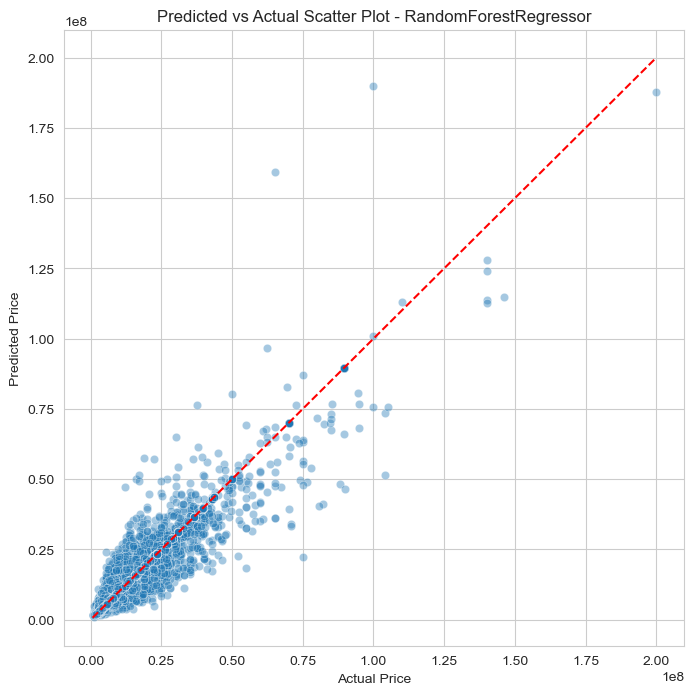

Best model: RandomForestRegressor
                       model           mae          rmse        r2
0      RandomForestRegressor  9.516009e+05  2.985314e+06  0.949651
1  GradientBoostingRegressor  2.473308e+06  4.271306e+06  0.896930
2           LinearRegression  4.125186e+06  6.480556e+06  0.762735


In [47]:
best_model_name = results_df.iloc[0]['model']
best_pipeline = pipelines[best_model_name]
best_predictions = predictions[best_model_name]

plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_test, y=best_predictions, alpha=0.4)
min_value = float(min(y_test.min(), best_predictions.min()))
max_value = float(max(y_test.max(), best_predictions.max()))
plt.plot([min_value, max_value], [min_value, max_value], color='red', linestyle='--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'Predicted vs Actual Scatter Plot - {best_model_name}')
plt.show()

print('Best model:', best_model_name)
print(results_df)

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(best_pipeline, X, y, cv=kf, scoring='r2', n_jobs=-1)
print('5-Fold CV R2 Scores:', cv_scores)
print('Mean CV R2:', cv_scores.mean())

### Best Model Rationale

The best model is selected using test-set error metrics, with RMSE weighted heavily because the task is a regression problem where large misses matter. R? is used as a secondary check to confirm that the model explains a useful amount of variance. The final choice balances accuracy and stability on unseen data.

## 11. Export

We export the trained model as `house_price.pkl`, save the cleaned location list to `locations.json`, reload the model, and verify that prediction works.

In [ ]:
model_path = OUTPUT_DIR / 'house_price.pkl'
locations_path = OUTPUT_DIR / 'locations.json'

dump(best_pipeline, model_path)
import os

size_mb = os.path.getsize(model_path) / (1024 * 1024)
print(f"Model size: {size_mb:.2f} MB")
locations = sorted(clean_df['location'].fillna('other').unique().tolist()) if 'location' in clean_df.columns else []
with locations_path.open('w', encoding='utf-8') as file_handle:
    json.dump(locations, file_handle, indent=2)

reloaded_model = load(model_path)
sample_prediction = reloaded_model.predict(X_test.iloc[:1])
print('Saved model to:', model_path)
print('Saved locations to:', locations_path)
print('Sample prediction:', sample_prediction[0])

Model size: 44.77 MB
Saved model to: G:\ML-house-price\notebooks\house_price.pkl
Saved locations to: G:\ML-house-price\notebooks\locations.json
Sample prediction: 4097000.0


In [ ]:
import os
from joblib import dump

for name, pipeline in pipelines.items():
    filename = OUTPUT_DIR / f"{name}.pkl"
    dump(pipeline, filename)

    size = os.path.getsize(filename) / (1024 * 1024)
    print(f"{name}: {size:.2f} MB")

LinearRegression: 0.01 MB
RandomForestRegressor: 44.77 MB
GradientBoostingRegressor: 0.15 MB


## Final Validation

| Requirement | Status |
|---|---|
| Project Introduction |  Completed |
| Import Libraries |  Completed |
| Load Dataset |  Completed |
| Exploratory Data Analysis |  Completed |
| Data Cleaning |  Completed |
| Feature Engineering |  Completed |
| Train/Test Split |  Completed |
| Machine Learning Pipeline |  Completed |
| Train Models |  Completed |
| Evaluation |  Completed |
| Export |  Completed |

The notebook is structured to run from top to bottom with all variables defined before use.